In [56]:
import cvxpy as cp
import numpy as np
import json

# Step 1: Load the options data from a JSON file
with open('options_data.json', 'r') as f:
    options_data = json.load(f)

# Step 2: Filter and extract relevant data
filtered_options = [option for option in options_data if float(option['lastPrice']) > 0 and float(option['markIv']) > 0]

# Extract option symbols, last prices, and implied volatilities
symbols = [option['symbol'] for option in filtered_options]
last_prices = np.array([float(option['lastPrice']) for option in filtered_options])
implied_vols = np.array([float(option['markIv']) for option in filtered_options])
gamma_values = np.array([float(option['gamma']) for option in filtered_options])  # Gamma as an alternative risk measure
vega_values = np.array([float(option['vega']) for option in filtered_options])  # Vega as an alternative risk measure

# Normalize the last prices (optional step)
last_prices = last_prices / np.sum(last_prices)

# Define capital (in USD)
capital = 20_000.0  # Total capital to allocate in USD

# Risk-free rate (we'll assume it to be 0 for simplicity)
risk_free_rate = 0

# Define the decision variable (weights of the portfolio)
weights = cp.Variable(len(last_prices))

# Portfolio return (sum of individual option returns multiplied by their weights)
portfolio_return = last_prices @ weights

# Using implied volatilities as risk
# Tends to focus the allocation on a few options with favorable return-to-volatility ratios.
portfolio_risk = cp.norm(implied_vols @ weights, 2)

# Using gamma as risk
# Provides more balanced diversification but still tends to favor options that have a more direct price sensitivity (gamma).
# portfolio_risk = cp.norm(gamma_values @ weights, 2)  

# Using vega as risk
# Leads to more equal allocation across several options, which may be useful if you want broader diversification with respect to volatility sensitivity.
# portfolio_risk = cp.norm(vega_values @ weights, 2)

# Define risk aversion parameter (adjust this to control the risk-return tradeoff)
risk_aversion = 5.0  # Adjust to control the balance between return and risk

# Objective: maximize return minus risk penalty (risk aversion * portfolio_risk)
objective = cp.Maximize(portfolio_return - risk_aversion * portfolio_risk)

# Constraints: no short-selling (weights >= 0), sum of weights is 1, and cap each option's weight to 10%
constraints = [weights >= 0, cp.sum(weights) == 1, weights <= 0.1]

# Step 4: Define and solve the problem
problem = cp.Problem(objective, constraints)
problem.solve()

# Output the optimized weights
optimized_weights = weights.value

# Convert weights to USD allocation based on total capital
usd_allocation = capital * optimized_weights

# Convert scientific notation to readable decimals and round to two decimal places
readable_usd_allocation = [round(float(alloc), 2) for alloc in usd_allocation]

# Filter out instruments with no allocation
filtered_allocation_mapping = [(symbol, alloc) for symbol, alloc in zip(symbols, readable_usd_allocation) if alloc > 0]

# Separate the calls and puts
calls = [(symbol, usd_alloc) for symbol, usd_alloc in filtered_allocation_mapping if 'C' in symbol.split('-')[-1]]
puts = [(symbol, usd_alloc) for symbol, usd_alloc in filtered_allocation_mapping if 'P' in symbol.split('-')[-1]]

# Print call options
print("\nUSD Allocations for Call Options:")
for symbol, usd_alloc in calls:
    print(f"{symbol}: {usd_alloc} USD")

# Print put options
print("\nUSD Allocations for Put Options:")
for symbol, usd_alloc in puts:
    print(f"{symbol}: {usd_alloc} USD")

# Also print the total allocated to ensure it sums to the total capital
print(f"Total Capital Allocated (should be close to {capital}):", sum(readable_usd_allocation))



USD Allocations for Call Options:
BTC-11OCT24-62500-C: 2000.0 USD
BTC-11OCT24-64000-C: 2000.0 USD
BTC-11OCT24-63000-C: 2000.0 USD
BTC-11OCT24-61500-C: 2000.0 USD
BTC-11OCT24-62000-C: 2000.0 USD
BTC-11OCT24-63500-C: 2000.0 USD

USD Allocations for Put Options:
BTC-11OCT24-62500-P: 2000.0 USD
BTC-11OCT24-64000-P: 2000.0 USD
BTC-11OCT24-63000-P: 2000.0 USD
BTC-11OCT24-62000-P: 2000.0 USD
Total Capital Allocated (should be close to 20000.0): 20000.0


In [45]:
import cvxpy as cp
import numpy as np
import json

# Load the options data from a JSON file
with open('options_data.json', 'r') as f:
    options_data = json.load(f)

# Filter and extract relevant data
filtered_options = [option for option in options_data if float(option['lastPrice']) > 0 and float(option['markIv']) > 0]

# Extract option symbols, last prices, and implied volatilities
symbols = [option['symbol'] for option in filtered_options]
last_prices = np.array([float(option['lastPrice']) for option in filtered_options])
implied_vols = np.array([float(option['markIv']) for option in filtered_options])

# Number of Monte Carlo simulations and time steps
num_simulations = 1000
num_steps = 10  # Simulate 10 periods (e.g., 5 minutes, depending on time step)

# Set simulation parameters
risk_free_rate = 0.0  # Assume zero drift for simplicity
delta_t = 1 / 252  # Assuming each step is one trading day, adjust as needed

# Initialize a matrix to store simulated returns for each option
simulated_returns = np.zeros((num_simulations, len(last_prices)))

# Monte Carlo simulation of future returns
np.random.seed(42)  # For reproducibility
for i in range(len(last_prices)):
    S0 = last_prices[i]
    sigma = implied_vols[i]
    
    # Simulate price paths
    for sim in range(num_simulations):
        path = S0
        for step in range(num_steps):
            Z = np.random.normal()
            path *= np.exp((risk_free_rate - 0.5 * sigma**2) * delta_t + sigma * np.sqrt(delta_t) * Z)
        # Store the final return (price change)
        simulated_returns[sim, i] = (path - S0) / S0  # Return over time

# Define the decision variable (weights of the portfolio)
weights = cp.Variable(len(last_prices))

# Portfolio return: use last prices
portfolio_return = last_prices @ weights

# Portfolio risk: using implied volatilities (or other risk metrics like vega or gamma)
portfolio_risk = cp.norm(implied_vols @ weights, 2)

# Define risk aversion parameter
risk_aversion = 5.0

# Objective: maximize return minus risk
objective = cp.Maximize(portfolio_return - risk_aversion * portfolio_risk)

# Constraints: no short-selling, sum of weights is 1, cap each option's weight to 10%
constraints = [weights >= 0, cp.sum(weights) == 1, weights <= 0.1]

# Add Monte Carlo-based risk constraint
# Ensure that under the Monte Carlo simulations, the portfolio doesn't lose more than a threshold
for sim in range(num_simulations):
    portfolio_sim_return = simulated_returns[sim, :] @ weights
    constraints.append(portfolio_sim_return >= -0.05)  # Example constraint: no more than 5% loss

# Solve the optimization problem
problem = cp.Problem(objective, constraints)
problem.solve()

# Output the optimized weights
optimized_weights = weights.value

# Convert weights to USD allocation based on total capital
capital = 100.0  # Total capital to allocate in USD
usd_allocation = capital * optimized_weights

# Filter out instruments with no allocation
filtered_allocation_mapping = [(symbol, alloc) for symbol, alloc in zip(symbols, usd_allocation) if alloc > 0]

# Separate the calls and puts
calls = [(symbol, usd_alloc) for symbol, usd_alloc in filtered_allocation_mapping if 'C' in symbol.split('-')[-1]]
puts = [(symbol, usd_alloc) for symbol, usd_alloc in filtered_allocation_mapping if 'P' in symbol.split('-')[-1]]

# Sort calls and puts by USD allocation in descending order
calls_sorted = sorted(calls, key=lambda x: x[1], reverse=True)
puts_sorted = sorted(puts, key=lambda x: x[1], reverse=True)

# Print call options
print("\nUSD Allocations for Call Options (sorted by highest allocation):")
for symbol, usd_alloc in calls_sorted:
    print(f"{symbol}: {usd_alloc:.2f} USD")

# Print put options
print("\nUSD Allocations for Put Options (sorted by highest allocation):")
for symbol, usd_alloc in puts_sorted:
    print(f"{symbol}: {usd_alloc:.2f} USD")

# Also print the total allocated to ensure it sums to the total capital
print("Total Capital Allocated (should be close to 100):", sum(usd_allocation))



USD Allocations for Call Options (sorted by highest allocation):
BTC-25OCT24-58000-C: 7.21 USD
BTC-25OCT24-56000-C: 6.78 USD
BTC-25OCT24-54000-C: 5.48 USD
BTC-25OCT24-96000-C: 4.52 USD
BTC-25OCT24-57000-C: 4.22 USD
BTC-25OCT24-94000-C: 3.49 USD
BTC-25OCT24-62000-C: 3.25 USD
BTC-25OCT24-90000-C: 2.57 USD
BTC-25OCT24-38000-C: 2.25 USD
BTC-25OCT24-52000-C: 2.19 USD
BTC-25OCT24-42000-C: 2.01 USD
BTC-25OCT24-63000-C: 1.65 USD
BTC-25OCT24-59000-C: 0.97 USD
BTC-25OCT24-68000-C: 0.66 USD
BTC-25OCT24-60000-C: 0.65 USD
BTC-25OCT24-98000-C: 0.59 USD
BTC-25OCT24-88000-C: 0.12 USD
BTC-25OCT24-92000-C: 0.12 USD
BTC-25OCT24-80000-C: 0.05 USD
BTC-25OCT24-64000-C: 0.00 USD

USD Allocations for Put Options (sorted by highest allocation):
BTC-25OCT24-94000-P: 8.11 USD
BTC-25OCT24-98000-P: 8.05 USD
BTC-25OCT24-96000-P: 7.62 USD
BTC-25OCT24-80000-P: 6.58 USD
BTC-25OCT24-70000-P: 5.40 USD
BTC-25OCT24-64000-P: 3.37 USD
BTC-25OCT24-68000-P: 3.28 USD
BTC-25OCT24-63000-P: 2.86 USD
BTC-25OCT24-48000-P: 1.58 USD

In [8]:
pip install QuantLib-Python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.6/19.6 MB 1.8 MB/s eta 0:00:00a 0:00:02
Note: you may need to restart the kernel to use updated packages.


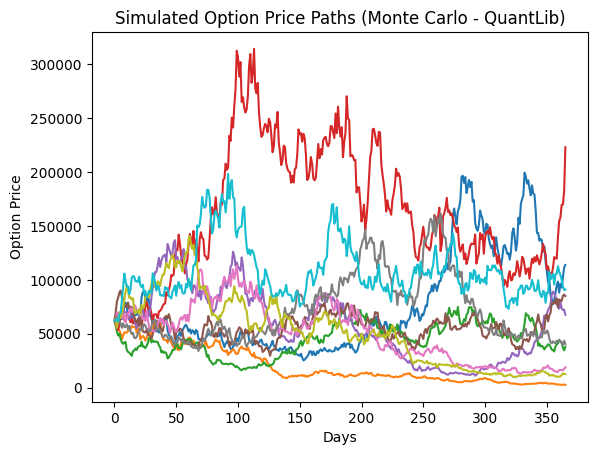

Simulated Final Prices after 4 days: [113898.30436777   2496.14754765  37891.53734397 223154.82272603
  67597.20813527  85061.70069007  18864.17030014  40396.8670822
  12543.16041345  90962.63401465]


In [25]:
import QuantLib as ql
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime

# Load your option data from a file
with open('options_data.json') as f:
    options_data = json.load(f)

# Current date (today)
current_date = datetime.today()

# Parse the expiry date from each option symbol and calculate maturity
def parse_expiry(symbol):
    # Assuming the symbol format is something like 'BTC-11OCT24-62000-P'
    expiry_str = symbol.split('-')[1]
    return datetime.strptime(expiry_str, '%d%b%y')

# Example: Parse all maturities in the data
maturities = [(parse_expiry(option['symbol']) - current_date).days / 365.0 for option in options_data]

# Define QuantLib settings
calendar = ql.NullCalendar()
day_count = ql.Actual365Fixed()
today = ql.Date(current_date.day, current_date.month, current_date.year)
ql.Settings.instance().evaluationDate = today

# Example for the first option (you can adjust for each option in a loop)
initial_price = float(options_data[0]["underlyingPrice"])
volatility = float(options_data[0]["markIv"])  # Implied volatility
risk_free_rate = 0.05  # Risk-free rate (annual)
maturity = maturities[0]  # Maturity from JSON data
expiry_date = ql.Date(parse_expiry(options_data[0]['symbol']).day,
                      parse_expiry(options_data[0]['symbol']).month,
                      parse_expiry(options_data[0]['symbol']).year)

# Set up the Black-Scholes process
spot_handle = ql.QuoteHandle(ql.SimpleQuote(initial_price))
volatility_handle = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(today, calendar, volatility, day_count))
rate_handle = ql.YieldTermStructureHandle(ql.FlatForward(today, risk_free_rate, day_count))

bsm_process = ql.BlackScholesProcess(spot_handle, rate_handle, volatility_handle)

# Monte Carlo Simulation settings
time_steps = 365  # Number of time steps (daily)
num_paths = 1000  # Number of simulation paths

# Create time grid
maturity_in_days = int(maturity * 365)
time_grid = ql.TimeGrid(maturity_in_days, time_steps)

# Create a random number generator
rng = ql.GaussianRandomSequenceGenerator(
    ql.UniformRandomSequenceGenerator(len(time_grid) - 1, ql.UniformRandomGenerator()))  # Fix: using len(time_grid)
seq = ql.GaussianPathGenerator(bsm_process, time_grid, rng, False)

# Simulate paths
def generate_paths(num_paths, num_steps):
    paths = np.zeros((num_paths, num_steps + 1))
    for i in range(num_paths):
        sample_path = seq.next()
        path = sample_path.value()
        time = [path.time(j) for j in range(len(path))]
        values = [path[j] for j in range(len(path))]
        paths[i, :] = np.array(values)
    return paths

# Simulate and plot
paths = generate_paths(num_paths, time_steps)

# Example: Plot the first 10 simulated paths
for i in range(10):
    plt.plot(paths[i], label=f"Path {i+1}")
plt.title('Simulated Option Price Paths (Monte Carlo - QuantLib)')
plt.xlabel('Days')
plt.ylabel('Option Price')
plt.show()

# Example: Extract the final prices (after maturity) for use in optimization
final_prices = paths[:, -1]
print(f"Simulated Final Prices after {maturity_in_days} days: {final_prices[:10]}")


In [61]:
import QuantLib as ql
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import json
import pandas as pd
from datetime import datetime

# Load option data
with open('options_data.json') as f:
    options_data = json.load(f)

# Current date (today)
current_date = datetime.today()

# Parse the expiry date from each option symbol and calculate maturity
def parse_expiry(symbol):
    expiry_str = symbol.split('-')[1]
    return datetime.strptime(expiry_str, '%d%b%y')

# Set up QuantLib parameters
calendar = ql.NullCalendar()
day_count = ql.Actual365Fixed()
today = ql.Date(current_date.day, current_date.month, current_date.year)
ql.Settings.instance().evaluationDate = today

# Simulate returns for the first 5 options in the data
num_options = 5
initial_prices = [float(options_data[i]["underlyingPrice"]) for i in range(num_options)]
volatilities = [float(options_data[i]["markIv"]) for i in range(num_options)]
maturities = [(parse_expiry(options_data[i]["symbol"]) - current_date).days / 365.0 for i in range(num_options)]

# Monte Carlo Simulation settings
time_steps = 365  # Daily time steps
num_paths = 1000  # Number of simulation paths

simulated_returns_list = []

for i in range(num_options):
    # Set up the Black-Scholes process for each option
    spot_handle = ql.QuoteHandle(ql.SimpleQuote(initial_prices[i]))
    volatility_handle = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(today, calendar, volatilities[i], day_count))
    rate_handle = ql.YieldTermStructureHandle(ql.FlatForward(today, 0.05, day_count))

    bsm_process = ql.BlackScholesProcess(spot_handle, rate_handle, volatility_handle)

    # Create time grid
    maturity_in_days = int(maturities[i] * 365)
    time_grid = ql.TimeGrid(maturity_in_days, time_steps)

    # Create a random number generator
    rng = ql.GaussianRandomSequenceGenerator(
        ql.UniformRandomSequenceGenerator(len(time_grid) - 1, ql.UniformRandomGenerator()))
    seq = ql.GaussianPathGenerator(bsm_process, time_grid, rng, False)

    # Simulate paths
    def generate_paths(num_paths, num_steps):
        paths = np.zeros((num_paths, num_steps + 1))
        for j in range(num_paths):
            sample_path = seq.next()
            path = sample_path.value()
            values = [path[k] for k in range(len(path))]
            paths[j, :] = np.array(values)
        return paths

    paths = generate_paths(num_paths, time_steps)
    
    # Calculate returns as percentage changes
    returns = np.diff(paths, axis=1) / paths[:, :-1]
    simulated_returns_list.append(np.mean(returns, axis=1))  # Only take the mean return for each option

# Stack simulated returns into a matrix (num_options x num_paths)
simulated_returns_matrix = np.vstack(simulated_returns_list)

# Calculate covariance matrix based on simulated returns
cov_matrix = np.cov(simulated_returns_matrix)

# Ensure covariance matrix is correctly sized
assert cov_matrix.shape == (num_options, num_options), f"Covariance matrix must be square. Found shape: {cov_matrix.shape}"

# --- Portfolio Optimization Code (CVXPY) ---

# Define portfolio optimization variables
weights = cp.Variable(num_options)

# Portfolio return (dot product of average_returns and weights)
average_returns = np.mean(simulated_returns_matrix, axis=1)
portfolio_return = cp.sum(cp.multiply(average_returns, weights))

# Portfolio risk (variance using the covariance matrix)
portfolio_variance = cp.quad_form(weights, cov_matrix)

# Set a target risk level (variance). You can adjust this based on your risk tolerance.
max_risk = 0.05  # Increased risk tolerance

# Objective: Maximize portfolio return
objective = cp.Maximize(portfolio_return)

# Constraints: Risk constraint (variance <= max_risk), weights sum to 1, no short selling, and diversification
constraints = [portfolio_variance <= max_risk, cp.sum(weights) == 1, weights >= 0]

# Add diversification constraint: no single option can exceed 30% of total allocation
diversification_limit = 0.3
constraints.append(weights <= diversification_limit)

# Define and solve the problem
problem = cp.Problem(objective, constraints)
problem.solve()

# Output optimized weights
optimized_weights = weights.value
print("Optimized Weights:", optimized_weights)

# Allocate capital based on the optimized weights
capital = 100  # Example: $100 to allocate
usd_allocation = capital * optimized_weights

# Get the symbols from options_data
symbols = [options_data[i]["symbol"] for i in range(num_options)]

# Format the allocation to avoid scientific notation
readable_allocation = {symbols[i]: round(usd_allocation[i], 2) for i in range(num_options)}

# Separate calls and puts into different tables
calls = []
puts = []
for symbol, allocation in readable_allocation.items():
    if '-C' in symbol:
        calls.append({"Option": symbol, "USD Allocation": allocation})
    elif '-P' in symbol:
        puts.append({"Option": symbol, "USD Allocation": allocation})

# Convert to pandas DataFrame for better presentation
calls_df = pd.DataFrame(calls)
puts_df = pd.DataFrame(puts)

# Display results
print("Calls Allocation:")
print(calls_df)
print("\nPuts Allocation:")
print(puts_df)


Optimized Weights: [2.99999900e-01 1.00325612e-04 9.99001328e-02 2.99999757e-01
 2.99999884e-01]
Calls Allocation:
                Option  USD Allocation
0  BTC-11OCT24-60000-C            30.0
1  BTC-11OCT24-70000-C            30.0

Puts Allocation:
                Option  USD Allocation
0  BTC-11OCT24-58000-P            0.01
1  BTC-11OCT24-72000-P            9.99
2  BTC-11OCT24-50000-P           30.00
